**Import Libraries & Load Data**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset using the specific Colab path
file_path = "/content/online_retail_II.csv"

try:
    df = pd.read_csv(file_path, encoding='unicode_escape')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check if the file is uploaded correctly.")

Dataset loaded successfully!


**Basic Information**

In [3]:
# Display dataset shape (rows and columns)
print("Dataset Shape:", df.shape)

# Display columns
print("\nColumns in Dataset:\n", df.columns.tolist())

# Display data types and non-null counts
print("\nData Types and Information:")
df.info()

# Display first 5 rows to understand the structure
df.head()

Dataset Shape: (306547, 8)

Columns in Dataset:
 ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types and Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306547 entries, 0 to 306546
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      306547 non-null  object 
 1   StockCode    306547 non-null  object 
 2   Description  304380 non-null  object 
 3   Quantity     306547 non-null  int64  
 4   InvoiceDate  306547 non-null  object 
 5   Price        306547 non-null  float64
 6   Customer ID  241075 non-null  float64
 7   Country      306547 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 18.7+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


**Missing Values & Duplicates**

In [4]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values[missing_values > 0])

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_rows}")

# Note: As per instructions, we are NOT removing any data.

Missing Values per Column:
 Description     2167
Customer ID    65472
dtype: int64

Total Duplicate Rows: 3649


**Revenue Calculation**

In [5]:
# Calculate Revenue (Quantity * Unit Price)
df['Revenue'] = df['Quantity'] * df['Price']

print("Revenue column added successfully. Preview:")
df[['Quantity', 'Price', 'Revenue']].head()

Revenue column added successfully. Preview:


,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


**Top 10 Best-Selling Products**

In [6]:
# Top 10 products by Quantity
top_products_qty = df.groupby('Description')['Quantity'].sum().nlargest(10)

# Top 10 products by Revenue
top_products_rev = df.groupby('Description')['Revenue'].sum().nlargest(10)

print("Top 10 Best-Selling Products (By Quantity):\n", top_products_qty)
print("\nTop 10 Best-Selling Products (By Revenue):\n", top_products_rev)

Top 10 Best-Selling Products (By Quantity):
 Description
PACK OF 72 RETRO SPOT CAKE CASES       38379
WHITE HANGING HEART T-LIGHT HOLDER     38065
WORLD WAR 2 GLIDERS ASSTD DESIGNS      30034
60 TEATIME FAIRY CAKE CASES            25788
BLACK AND WHITE PAISLEY FLOWER MUG     25701
ASSORTED COLOUR BIRD ORNAMENT          22509
PACK OF 12 RED SPOTTY TISSUES          21224
PACK OF 12 SUKI TISSUES                20623
COLOUR GLASS T-LIGHT HOLDER HANGING    20287
PACK OF 12 PINK PAISLEY TISSUES        19967
Name: Quantity, dtype: int64

Top 10 Best-Selling Products (By Revenue):
 Description
WHITE HANGING HEART T-LIGHT HOLDER    103454.04
DOTCOM POSTAGE                         72035.03
REGENCY CAKESTAND 3 TIER               71220.21
ASSORTED COLOUR BIRD ORNAMENT          36863.08
PARTY BUNTING                          34866.85
EDWARDIAN PARASOL NATURAL              26363.81
JUMBO BAG RED WHITE SPOTTY             25054.27
VINTAGE UNION JACK BUNTING             25047.61
TEA TIME CAKE STAND IN 

**Sales Performance by Country**

Top 10 Countries by Revenue:
 Country
United Kingdom    4715106.980
EIRE               226147.110
Netherlands        161292.090
Germany            117034.961
France              85741.630
Denmark             37564.520
Sweden              35167.220
Spain               20241.250
Switzerland         17779.880
Belgium             13011.130
Name: Revenue, dtype: float64


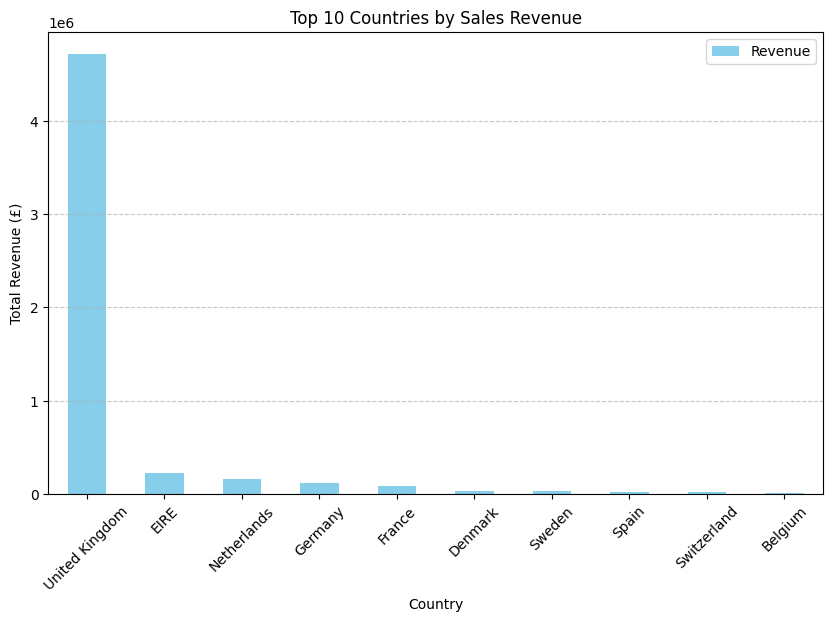

In [7]:
# Analyze revenue by country
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Display top 10 countries by revenue
print("Top 10 Countries by Revenue:\n", country_sales.head(10))

# Visualizing top 10 countries
plt.figure(figsize=(10, 6))
country_sales.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Sales Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.legend(['Revenue'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Revenue Over Time (Monthly Trend)**

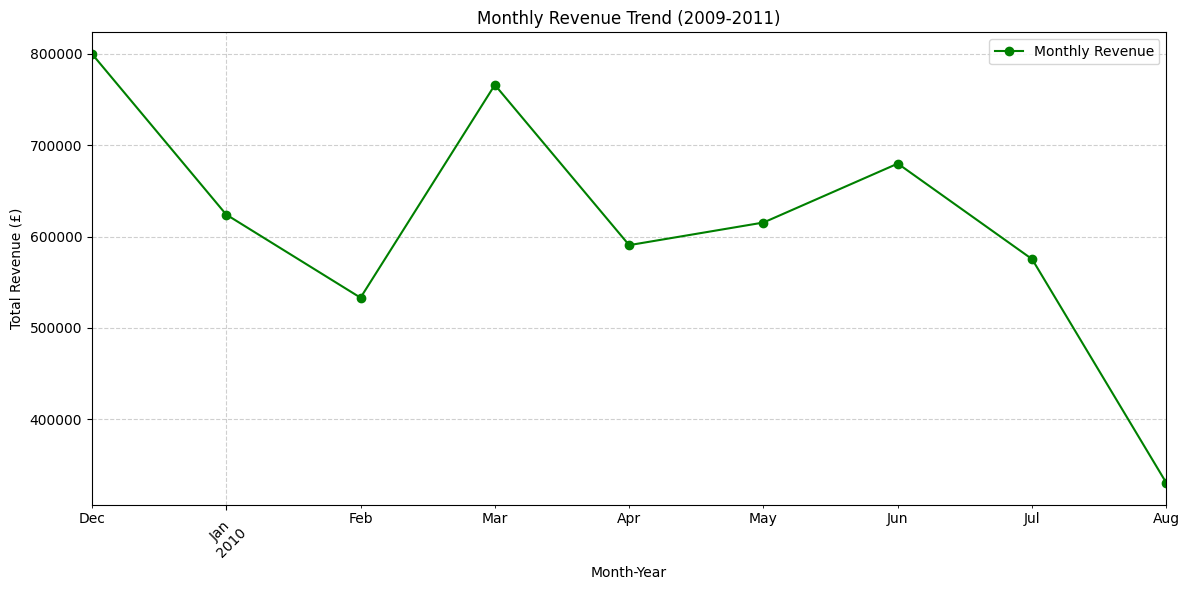

In [8]:
# Convert InvoiceDate to datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Year and Month for monthly grouping
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Group by Month and sum the revenue
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

# Plotting the monthly trend
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend (2009-2011)')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue (£)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(['Monthly Revenue'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Correlation Heatmap**

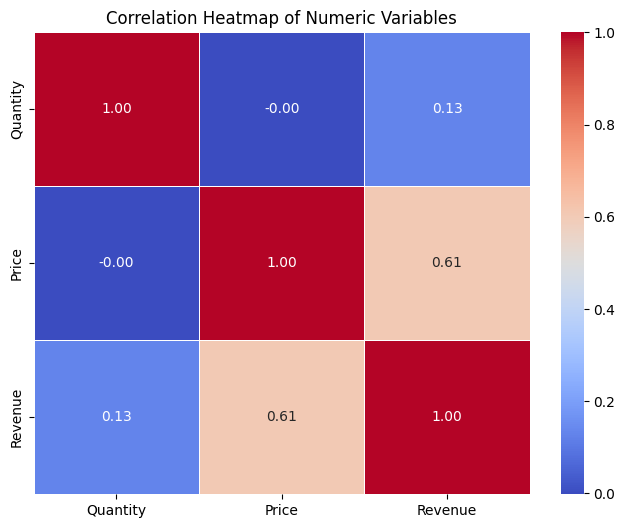

In [9]:
# Select only numeric columns for correlation
numeric_cols = df[['Quantity', 'Price', 'Revenue']]

# Calculate correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

**Detect and Visualize Outliers**

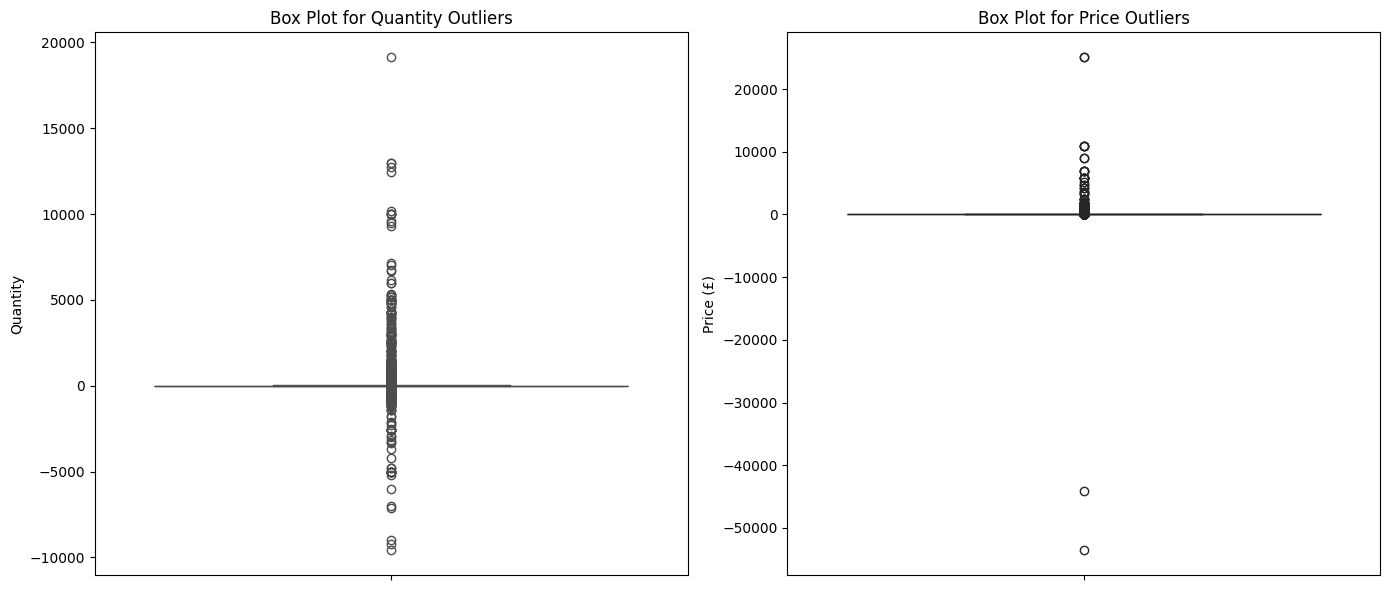

In [10]:
plt.figure(figsize=(14, 6))

# Boxplot for Quantity
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'], color='orange')
plt.title('Box Plot for Quantity Outliers')
plt.ylabel('Quantity')

# Boxplot for Price
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price'], color='purple')
plt.title('Box Plot for Price Outliers')
plt.ylabel('Price (£)')

plt.tight_layout()
plt.show()